ML Model File

In [150]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.svm import SVR
from sklearn.feature_selection import RFECV
from sklearn.preprocessing import PolynomialFeatures, StandardScaler
from sklearn.pipeline import make_pipeline

In [151]:
df = pd.read_csv("C:/Users/tanma/Downloads/solar_panel_model/phx_solar_power_2006.csv")

print(df.head())

# df['LocalTime'] = pd.to_datetime(df['LocalTime']) 
# df['Date'] = df['LocalTime'].dt.date
# df['Time'] = df['LocalTime'].dt.time

# print(df.head())

        LocalTime  Power(MW)
0  01/01/06 00:00        0.0
1  01/01/06 00:05        0.0
2  01/01/06 00:10        0.0
3  01/01/06 00:15        0.0
4  01/01/06 00:20        0.0


In [152]:
#converting time to separate fields

df['LocalTime'] = pd.to_datetime(df['LocalTime']) 
df['Date'] = df['LocalTime'].dt.date
df['Time'] = df['LocalTime'].dt.time

print(df.head())

C:\Users\tanma\AppData\Local\Temp\ipykernel_23432\2990489470.py:3: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  df['LocalTime'] = pd.to_datetime(df['LocalTime'])


            LocalTime  Power(MW)        Date      Time
0 2006-01-01 00:00:00        0.0  2006-01-01  00:00:00
1 2006-01-01 00:05:00        0.0  2006-01-01  00:05:00
2 2006-01-01 00:10:00        0.0  2006-01-01  00:10:00
3 2006-01-01 00:15:00        0.0  2006-01-01  00:15:00
4 2006-01-01 00:20:00        0.0  2006-01-01  00:20:00


The data is in 5 minute intervals, and for obvious reasons there would not be any solar power generation when there is dark out. So for this analysis and my model, id much rather aggregate the data across each day. 

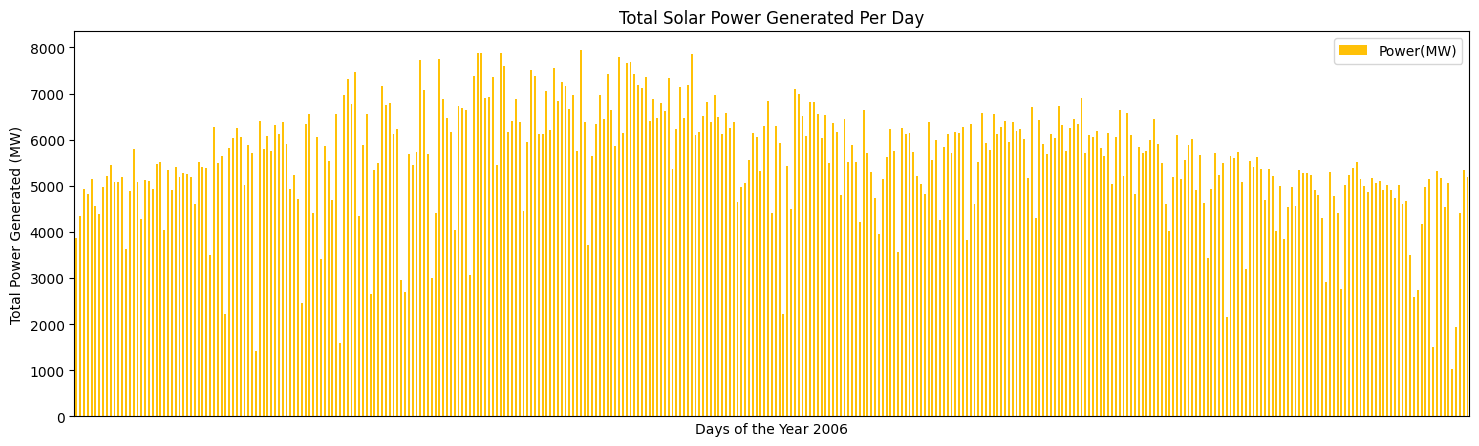

In [153]:
df_agg = df.groupby('Date').sum('Power(MW)').reset_index()
df_agg.plot(kind='bar', x='Date', y='Power(MW)', xlabel='Days of the Year 2006', ylabel='Total Power Generated (MW)', color='#FFC107') #DAA520, F4C430, FFDB58, FFC107 

plt.gca().xaxis.set_major_locator(plt.NullLocator())
plt.gca().set_title('Total Solar Power Generated Per Day')
plt.gcf().set_size_inches(18, 5)

Arizona is infamously a super sunny state throughout the year, so these trends (along w various peaks in the early part of the year) are expected

We can now load up the features we extracted using the NASA api

In [154]:
features = pd.read_csv("C:/Users/tanma/Downloads/solar_panel_model/phoenix_2006_weather.csv", header=0)

print(features.head())

         Date  Temperature_2m_C  Relative_Humidity_2m_%  Wind_Speed_2m_mps  \
0  2006-01-01             11.80                   44.51               1.20   
1  2006-01-02             14.83                   45.22               2.15   
2  2006-01-03             14.35                   48.32               1.03   
3  2006-01-04             13.51                   21.94               1.51   
4  2006-01-05             15.08                   20.54               3.29   

   Solar_Radiation_MJ/m2  daylight_hours  
0                   2.91        9.973761  
1                   2.79        9.982978  
2                   3.57        9.992995  
3                   3.55       10.003805  
4                   3.74       10.015396  


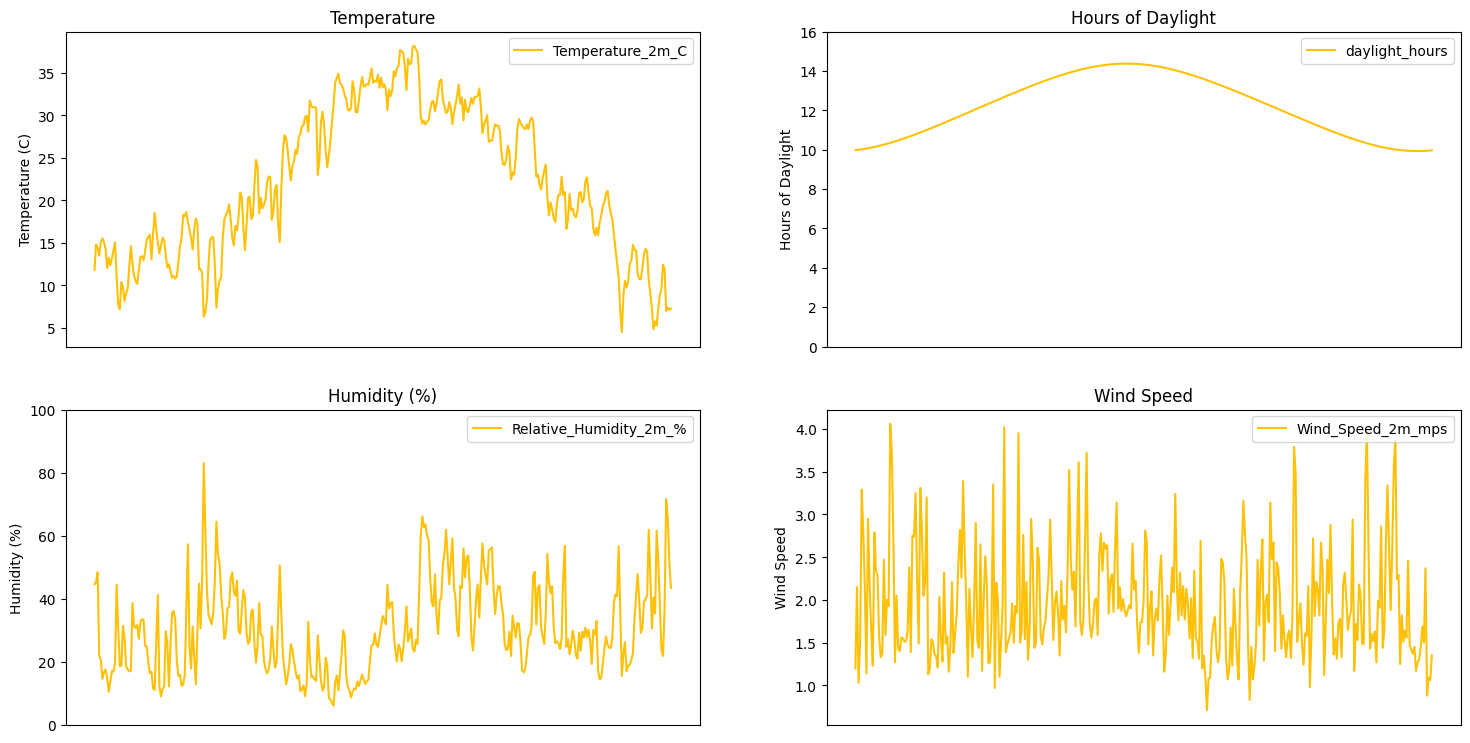

In [155]:
fig, axs = plt.subplots(nrows=2, ncols=2, figsize=(18, 9))

features.plot(kind='line', x='Date', y='Temperature_2m_C', ax=axs[0, 0], color='#FFC107')
axs[0, 0].set_xlabel('')
axs[0, 0].set_ylabel('Temperature (C)')
axs[0, 0].set_title('Temperature')
axs[0, 0].xaxis.set_major_locator(plt.NullLocator())

features.plot(kind='line', x='Date', y='daylight_hours', ax=axs[0, 1], color='#FFC107')
axs[0, 1].set_xlabel('')
axs[0, 1].set_ylabel('Hours of Daylight')
axs[0, 1].set_title('Hours of Daylight')
axs[0, 1].set_ylim(0, 16)
axs[0, 1].xaxis.set_major_locator(plt.NullLocator())

features.plot(kind='line', x='Date', y='Relative_Humidity_2m_%', ax=axs[1, 0], color='#FFC107')
axs[1, 0].set_xlabel('')
axs[1, 0].set_ylabel('Humidity (%)')
axs[1, 0].set_title('Humidity (%)')
axs[1, 0].set_ylim(0, 100)
axs[1, 0].legend(loc='upper right')
axs[1, 0].xaxis.set_major_locator(plt.NullLocator())

features.plot(kind='line', x='Date', y='Wind_Speed_2m_mps', ax=axs[1, 1], color='#FFC107')
axs[1, 1].set_xlabel('')
axs[1, 1].set_ylabel('Wind Speed')
axs[1, 1].set_title('Wind Speed')
axs[1, 1].legend(loc='upper right')
axs[1, 1].xaxis.set_major_locator(plt.NullLocator())


The objective of this project is to correlate solar power generated against all these features to see how each feature affects the solar power generated - so it is best to merge all of them into one dataset.

In [156]:
merge_df = df_agg.merge(features,on ='Date', how='right') #we will be using this merged dataset everywhere now - best to not constantly change it 
merge_df['Power(MW)'] = df_agg['Power(MW)']

print(merge_df.head())

         Date  Power(MW)  Temperature_2m_C  Relative_Humidity_2m_%  \
0  2006-01-01     3868.5             11.80                   44.51   
1  2006-01-02     4350.6             14.83                   45.22   
2  2006-01-03     4923.0             14.35                   48.32   
3  2006-01-04     4825.8             13.51                   21.94   
4  2006-01-05     5149.5             15.08                   20.54   

   Wind_Speed_2m_mps  Solar_Radiation_MJ/m2  daylight_hours  
0               1.20                   2.91        9.973761  
1               2.15                   2.79        9.982978  
2               1.03                   3.57        9.992995  
3               1.51                   3.55       10.003805  
4               3.29                   3.74       10.015396  


In [157]:
X = merge_df.drop('Power(MW)',axis=1)
X = X.drop('Date',axis=1)
y = merge_df['Power(MW)'].to_numpy().reshape(-1, 1)

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.1, random_state=40)

model = LinearRegression()
model.fit(X_train, y_train)

coeffs = pd.concat([pd.DataFrame(X.columns),pd.DataFrame(np.transpose(model.coef_))], axis=1, ignore_index=True)
coeffs.rename(columns={0: 'Feature', 1: 'Coefficient'}, inplace=True)
print(coeffs)

                  Feature  Coefficient
0        Temperature_2m_C    -9.575163
1  Relative_Humidity_2m_%     7.619399
2       Wind_Speed_2m_mps   138.769845
3   Solar_Radiation_MJ/m2  1046.734008
4          daylight_hours  -695.583827


The feature coefficients help us understand how different features tie into solar power generation. We can see +ve and -Ve correlations, and we can see how solar radiation is clearly the most defining factor (which if we think about it, makes sense). Daylight hours has a high -ve correlation, which can be confusing at first. The best way to understand this would be to use something like random forest to come up with normalised coefficients - we will do that later in this notebook.

For now, we will proceed to use linear regression on the test set to predict solar power generation using all the features - and we can compare them to the actual values and plot the values.

In [158]:
predictions = model.predict(X_test)

df_pred = pd.DataFrame(y_test)
df_pred.columns = ['ActualValue(MW)']

df_pred['PredValue(MW)'] = predictions
df_pred['PredValue(MW)'] = df_pred['PredValue(MW)'].apply(lambda value:round(value, 1))

df_pred['Difference'] = predictions - y_test
df_pred['Difference'] = df_pred['Difference'].apply(lambda value:round(value, 1))

df_pred['% Error'] = round(100*(df_pred['Difference']/df_pred['ActualValue(MW)']), 2)

print(df_pred)
print('\n')

print('Mean Difference:')
print(round(df_pred['Difference'].sum()/36, 1))
print('\n')
print('Mean Squared Difference')
print(round(df_pred['Difference'].apply(lambda value:value**2).sum()/36, 1))

    ActualValue(MW)  PredValue(MW)  Difference  % Error
0            6115.0         6521.2       406.2     6.64
1            4021.4         5357.5      1336.1    33.22
2            6066.6         5706.2      -360.4    -5.94
3            7948.4         6906.5     -1041.9   -13.11
4            6049.0         6129.8        80.8     1.34
5            5454.6         5045.8      -408.8    -7.49
6            4982.4         4100.7      -881.7   -17.70
7            1600.4         2219.3       618.9    38.67
8            5616.6         5234.0      -382.6    -6.81
9            7790.2         7090.3      -699.9    -8.98
10           4412.4         5132.4       720.0    16.32
11           6518.1         6553.9        35.8     0.55
12           4935.5         5057.2       121.7     2.47
13           5004.2         4959.4       -44.8    -0.90
14           4912.8         5032.4       119.6     2.43
15           6554.5         6354.7      -199.8    -3.05
16           4825.8         4686.6      -139.2  

We can plot the actual vs predicted values now using line charts and bar charts

<Axes: title={'center': 'Actual vs Predicted Solar Power (Line Chart)'}, xlabel='Date'>

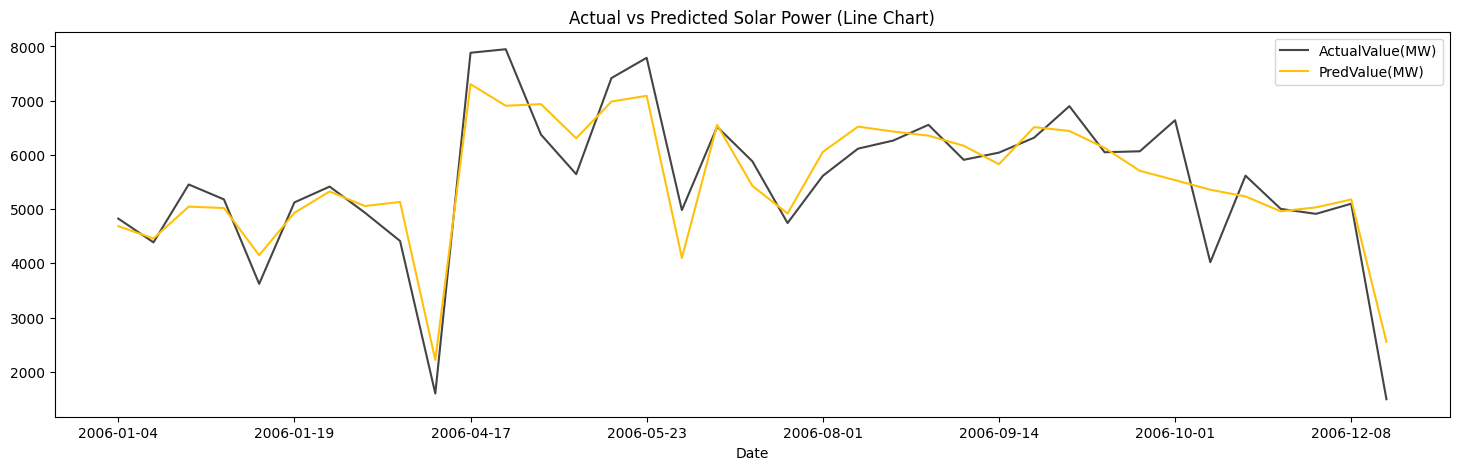

In [159]:
merge_test_df = df_pred.merge(merge_df,left_on='ActualValue(MW)', right_on='Power(MW)', how='left')
merge_test_df.sort_values(by=['Date'], inplace=True)
merge_test_df = merge_test_df.reset_index(drop=True)

merge_test_df.plot(x='Date',y=['ActualValue(MW)', 'PredValue(MW)'],kind='line',figsize=(18,5),title='Actual vs Predicted Solar Power (Line Chart)', color=['#444444', '#FFC107'])


<Axes: title={'center': 'Actual vs. Predicted Solar Power Generated (Bar chart)'}, ylabel='Total Power Generated (MW)'>

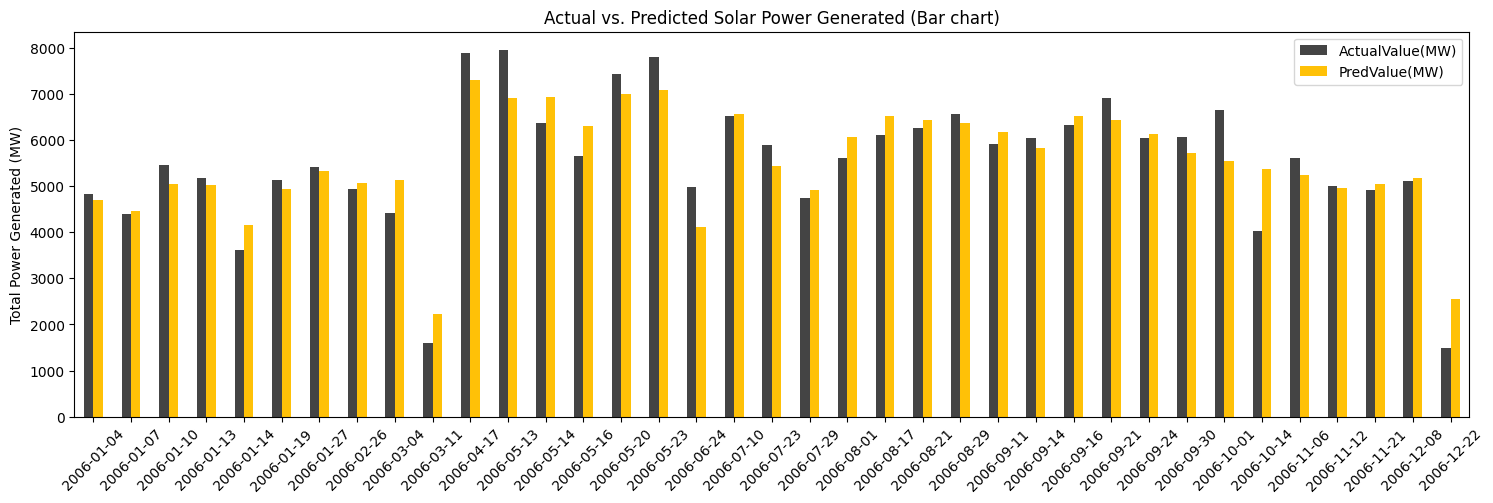

In [160]:
merge_test_df = df_pred.merge(merge_df,left_on='ActualValue(MW)', right_on='Power(MW)', how='left')
merge_test_df.sort_values(by=['Date'], inplace=True)
merge_test_df = merge_test_df.reset_index(drop=True)

merge_test_df.plot(x='Date', y=['ActualValue(MW)', 'PredValue(MW)'], xlabel='', ylabel='Total Power Generated (MW)', kind="bar", rot=45, color=['#444444', '#FFC107'], figsize=(18,5), title = 'Actual vs. Predicted Solar Power Generated (Bar chart)' )

Another good visualisation practice is to visualise errors

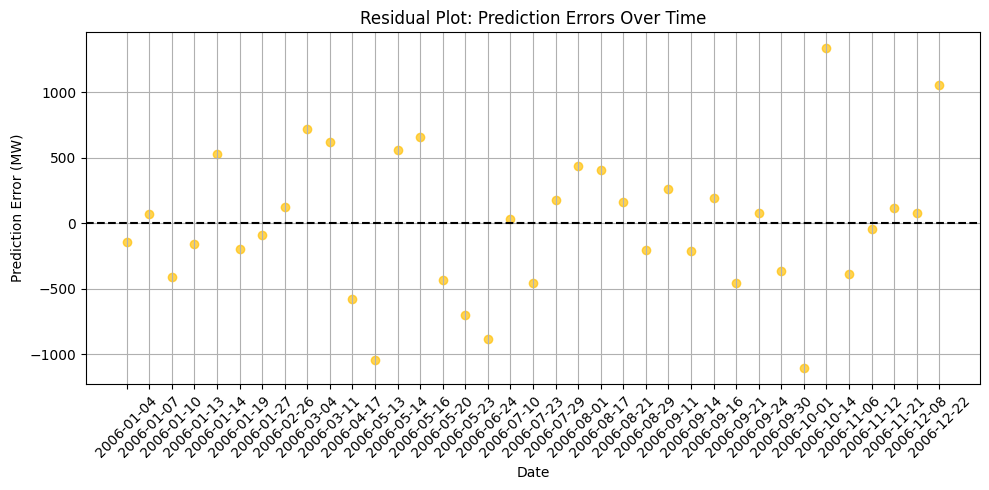

In [161]:
plt.figure(figsize=(10,5))
residuals = merge_test_df['PredValue(MW)'] - merge_test_df['ActualValue(MW)']
plt.scatter(merge_test_df['Date'], residuals, color='#FFC107', alpha=0.7)
plt.axhline(0, color='black', linestyle='--')
plt.ylabel('Prediction Error (MW)')
plt.xlabel('Date')
plt.title('Residual Plot: Prediction Errors Over Time')
plt.xticks(rotation=45)
plt.grid(True)
plt.tight_layout()
plt.show()

Another way to calculate feature importance can be to directly use random forest - it would normalise the values and make more sense out of the coefficients and their importance

In [162]:
from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import train_test_split
import pandas as pd
import numpy as np

# Prepare your features and target
X = merge_df.drop(['Power(MW)', 'Date'], axis=1)
y = merge_df['Power(MW)']

# Split the data
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.1, random_state=42)

# Initialize and fit the model
rf_model = RandomForestRegressor(n_estimators=100, random_state=42)
rf_model.fit(X_train, y_train)

# Get feature importances
importances = rf_model.feature_importances_
features = X.columns

# Create a DataFrame of feature importances
rf_importance_df = pd.DataFrame({'Feature': features,'Importance': importances}).sort_values(by='Importance', ascending=False)

# Show top features
print(rf_importance_df)


                  Feature  Importance
3   Solar_Radiation_MJ/m2    0.740744
4          daylight_hours    0.123624
0        Temperature_2m_C    0.060546
1  Relative_Humidity_2m_%    0.040781
2       Wind_Speed_2m_mps    0.034304


And ofc - we can always visualise this for an even simpler understanding.

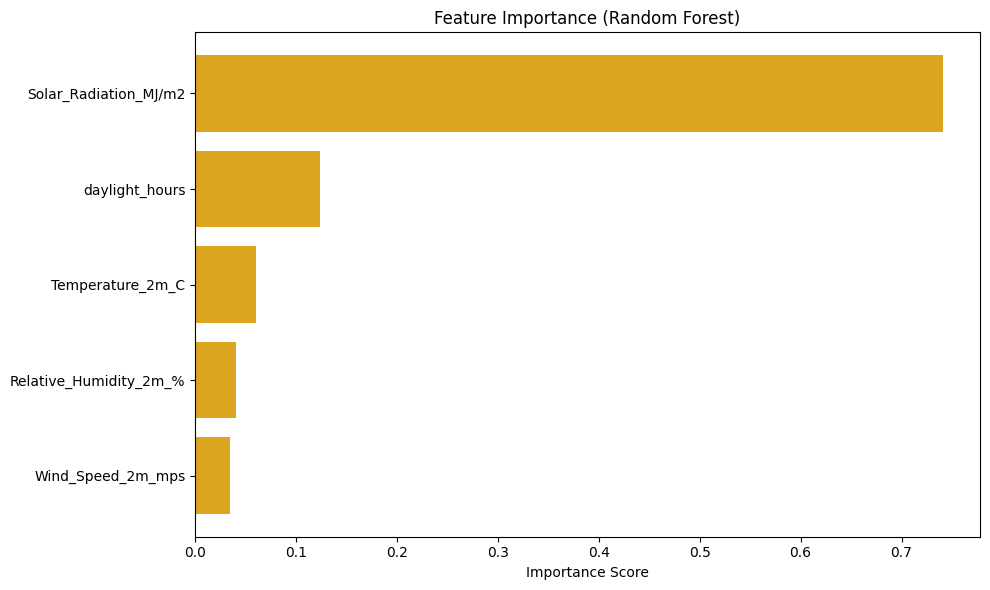

In [163]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10,6))
plt.barh(rf_importance_df['Feature'], rf_importance_df['Importance'], color='goldenrod')
plt.gca().invert_yaxis()  # Most important at the top
plt.title('Feature Importance (Random Forest)')
plt.xlabel('Importance Score')
plt.tight_layout()
plt.show()

In order to explore its usage, i also decided to use RFECV (recursive feature elimination with cross-validation) in order to understand what this ML mechanism deems to be the the optimal features for my analysis.

This works in two steps basically :
Recursive Feature Elimination (RFE) - trains the model, recursively removes the least important feature based on model performance and Repeats until it finds the best performing subset.
Cross-Validation (CV) - Validates how well it performs on unseen data

The subset of features with the best CV score is selected as optimal

It’s essentially automated feature selection based on model performance — useful to avoid overfitting and to reduce dimensionality.

In [164]:
X = merge_df.drop(['Power(MW)', 'Date'],axis=1)
y = merge_df['Power(MW)']

estimator = SVR(kernel='linear')
rfecv = RFECV(estimator, step=1, cv=5) #5 fold cross validation
rfecv.fit(X, y)

features = list(X.columns[rfecv.support_])  #rfecv.support_ gives a boolean mask for the selected features - which we are able to convert into a list
print('Optimal number of features: ', rfecv.n_features_)
print(features)

Optimal number of features:  1
['Solar_Radiation_MJ/m2']


This tells us that there is only one optimal feature - Solar Radiation. Lets try using just that for predictions.

In [165]:
X_2 = X.drop(['Temperature_2m_C', 'Relative_Humidity_2m_%','Wind_Speed_2m_mps','daylight_hours'],axis=1)
y_2 = merge_df['Power(MW)']

X_2_train, X_2_test, y_2_train, y_2_test = train_test_split(X_2, y_2, test_size=0.1, random_state=40)

model_2 = LinearRegression()
model_2.fit(X_2_train, y_2_train)


LinearRegression()

In [166]:
predictions_2 = model_2.predict(X_2_test)

predict_df_2 = pd.DataFrame(y_2_test)
predict_df_2.columns = ['ActualValue(MW)']

predict_df_2['PredValue(MW)'] = predictions_2
predict_df_2['PredValue(MW)'] = predict_df_2['PredValue(MW)'].apply(lambda value:round(value, 1))

predict_df_2['Difference'] = predictions_2 - y_2_test
predict_df_2['Difference'] = predict_df_2['Difference'].apply(lambda value:round(value, 1))

predict_df_2['% Error'] = round(100*(predict_df_2['Difference']/predict_df_2['ActualValue(MW)']), 2)

print('Mean Difference:')
print(round(predict_df_2['Difference'].sum()/36, 1))
print('\n')
print('Mean Squared Difference')
print(round(predict_df_2['Difference'].apply(lambda value:value**2).sum()/36, 1))

Mean Difference:
-9.1


Mean Squared Difference
593734.6


I was also curious to see how Polynomial regression would perform in this context as it helps capture non-linear relationships between the feature and the target. 
In order to carry this out, i decided to wrap the model into a pipeline (the internet keeps providing me with wonderful ways to write code) along with a standard scalar to normalise values. This prevents data leakage and also helps in deployment if ever needed.

In [167]:
X_3 = X_2
y_3 = merge_df['Power(MW)']

X_3_train, X_3_test, y_3_train, y_3_test = train_test_split(X_3, y_3, test_size=0.1, random_state=40)


model_poly = make_pipeline(PolynomialFeatures(degree=2), StandardScaler(), LinearRegression())
model_poly.fit(X_3_train, y_3_train)

predictions_poly = model_poly.predict(X_3_test)

df_pred_poly = pd.DataFrame(y_3_test)
df_pred_poly.columns = ['ActualValue(MW)']
df_pred_poly.reset_index()

df_pred_poly['PredValue(MW)'] = predictions_poly
df_pred_poly['PredValue(MW)'] = df_pred_poly['PredValue(MW)'].apply(lambda value:round(value, 1))

df_pred_poly['Difference'] = predictions_poly - y_3_test
df_pred_poly['Difference'] = df_pred_poly['Difference'].apply(lambda value:round(value, 1))

df_pred_poly['% Error'] = round(100*(df_pred_poly['Difference']/df_pred_poly['ActualValue(MW)']), 2)

print(df_pred_poly)
print('\n')
print('Mean Difference:')
print(round(df_pred_poly['Difference'].sum()/36, 1))
print('\n')
print('Mean Squared Difference')
print(round(df_pred_poly['Difference'].apply(lambda value:value**2).sum()/36, 1))

     ActualValue(MW)  PredValue(MW)  Difference  % Error
228           6115.0         6473.4       358.4     5.86
286           4021.4         5272.2      1250.8    31.10
272           6066.6         5863.5      -203.1    -3.35
132           7948.4         6667.2     -1281.2   -16.12
266           6049.0         5996.1       -52.9    -0.87
9             5454.6         4663.0      -791.6   -14.51
174           4982.4         5896.4       914.0    18.34
69            1600.4         2823.2      1222.8    76.41
309           5616.6         5003.0      -613.6   -10.92
142           7790.2         6712.6     -1077.6   -13.83
62            4412.4         5331.8       919.4    20.84
190           6518.1         6649.1       131.0     2.01
56            4935.5         5236.0       300.5     6.09
315           5004.2         4823.0      -181.2    -3.62
324           4912.8         4684.2      -228.6    -4.65
240           6554.5         6355.4      -199.1    -3.04
3             4825.8         43

<Axes: title={'center': 'Actual vs Predicted Solar Power (Line Chart)'}, xlabel='Date'>

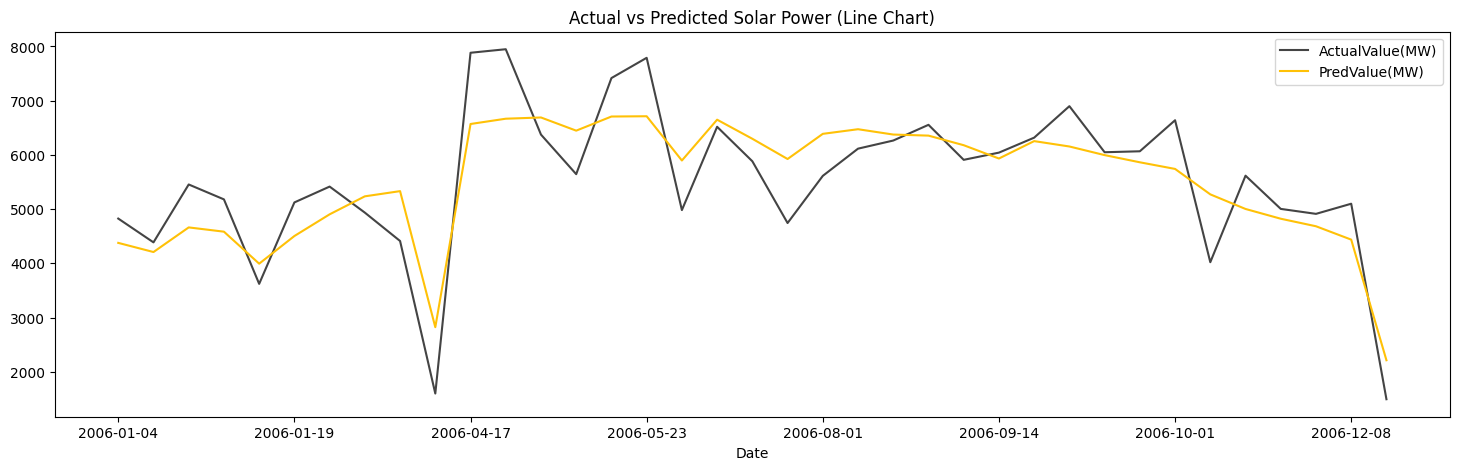

In [168]:
merge_test_df_poly = df_pred_poly.merge(merge_df,left_on='ActualValue(MW)', right_on='Power(MW)', how='left')
merge_test_df_poly.sort_values(by=['Date'], inplace=True)
merge_test_df_poly = merge_test_df_poly.reset_index(drop=True)

merge_test_df_poly.plot(x='Date',y=['ActualValue(MW)', 'PredValue(MW)'],kind='line',figsize=(18,5),title='Actual vs Predicted Solar Power (Line Chart)', color=['#444444', '#FFC107'])

<Axes: title={'center': 'Actual vs. Predicted Solar Power Generated (Bar Chart)'}, ylabel='Total Power Generated (MW)'>

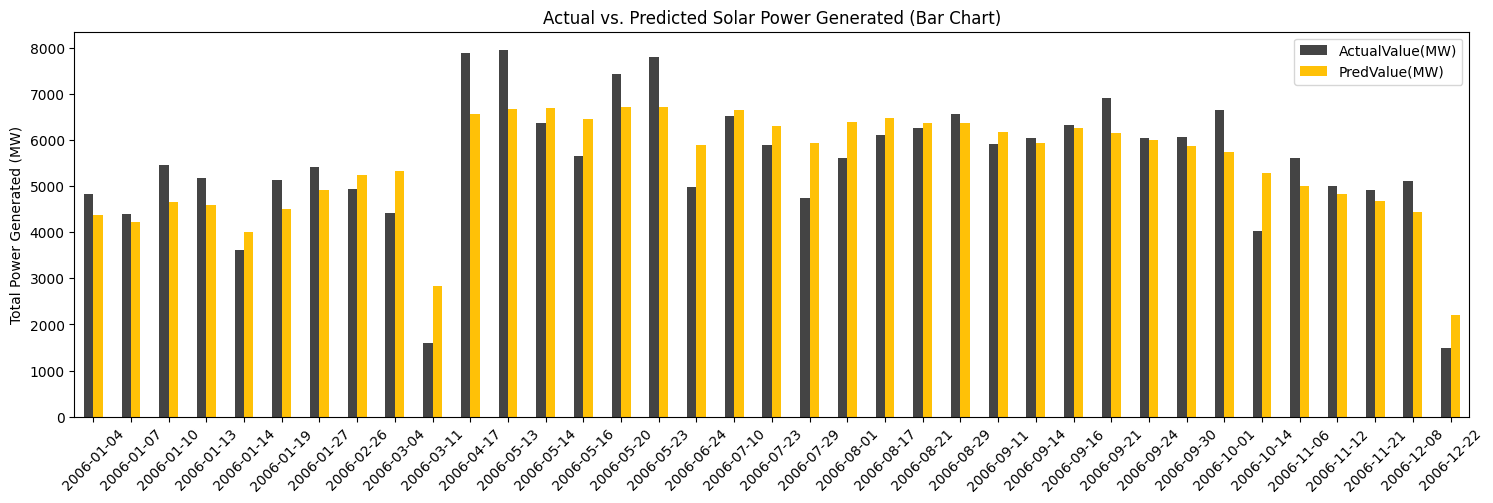

In [169]:
merge_test_df_poly = df_pred_poly.merge(merge_df,
                  left_on='ActualValue(MW)', right_on='Power(MW)', how='left')
merge_test_df_poly.sort_values(by=['Date'], inplace=True)
merge_test_df_poly = merge_test_df_poly.reset_index(drop=True)

merge_test_df_poly.plot(x='Date', y=['ActualValue(MW)', 'PredValue(MW)'], xlabel='', ylabel='Total Power Generated (MW)', kind="bar", rot=45, figsize=(18,5), color=['#444444', '#FFC107'], title = 'Actual vs. Predicted Solar Power Generated (Bar Chart)')


Final part of this notebook is just a comparitive analysis and a couple of graphs which took me way too long to code because of how frustrating it is to separately color each bar in a bar graph. But hey atleast i now know how to do it!

In [170]:
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

def evaluate_model(name, y_true, y_pred):
    diff = y_pred - y_true
    metrics = {
        'Model': name,
        'Mean Difference': round(diff.mean(), 2),
        'MAE': round(mean_absolute_error(y_true, y_pred), 2),
        'MSE': round(mean_squared_error(y_true, y_pred), 2),
        'R² Score': round(r2_score(y_true, y_pred), 3),
        'Average Error': round(100 * abs(diff / y_true).mean(), 2)
    }
    return metrics


In [171]:
results = []

y_pred = model.predict(X_test).ravel()
results.append(evaluate_model("Linear Regression", y_test.values.flatten(), y_pred))

y_2_pred = model_2.predict(X_2_test).ravel()
results.append(evaluate_model("Linear Regression After RFECV", y_2_test.values.flatten(), y_2_pred))

y_3_pred = model_poly.predict(X_3_test).ravel()
results.append(evaluate_model("Polynomial Regression (deg=2)", y_3_test.values.flatten(), y_3_pred))


In [172]:
comparison_df = pd.DataFrame(results)
comparison_df.set_index('Model', inplace=True)
print(comparison_df)

                               Mean Difference     MAE        MSE  R² Score  \
Model                                                                         
Linear Regression                      -118.15  433.26  266473.99     0.825   
Linear Regression After RFECV            -8.85  616.66  577691.89     0.702   
Polynomial Regression (deg=2)           -38.46  582.03  483037.57     0.750   

                               Average Error  
Model                                         
Linear Regression                       9.31  
Linear Regression After RFECV          15.78  
Polynomial Regression (deg=2)          12.81  


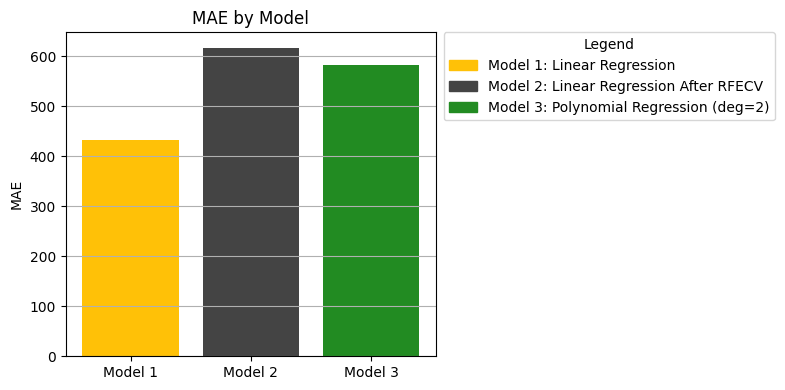

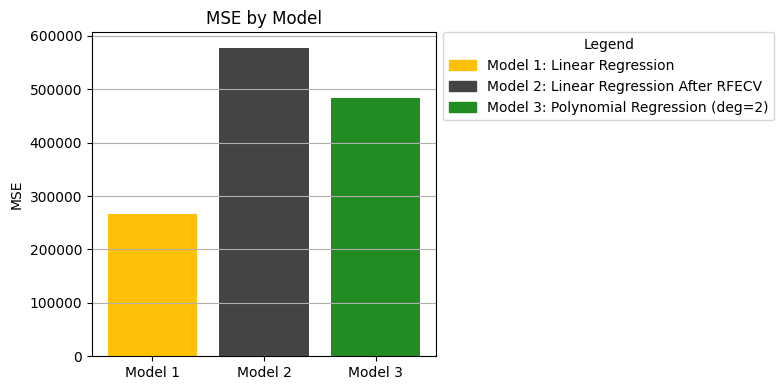

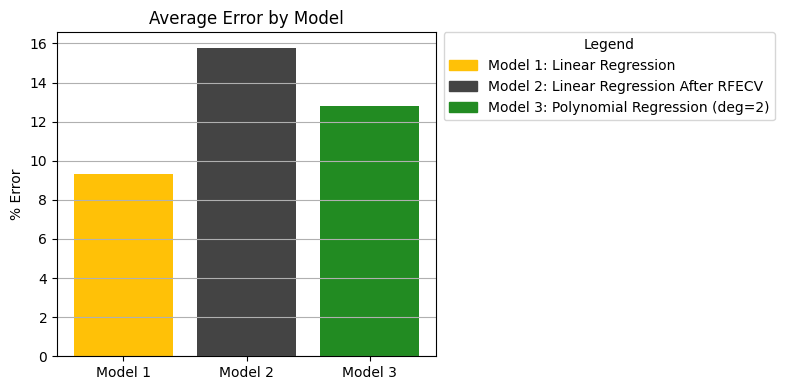

In [173]:
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import numpy as np

comparison_df.index = ['Model 1', 'Model 2', 'Model 3']

colors = ['#FFC107', '#444444', '#228B22']

legend_labels = {
    'Model 1': 'Linear Regression',
    'Model 2': 'Linear Regression After RFECV',
    'Model 3': 'Polynomial Regression (deg=2)'
}

legend_handles = [
    mpatches.Patch(color=color, label=f'{key}: {label}')
    for (key, label), color in zip(legend_labels.items(), colors)
]

# X-axis positions
x = np.arange(len(comparison_df.index))


# --- MAE Plot ---
plt.figure(figsize=(8, 4))
plt.bar(x, comparison_df['MAE'].values, color=colors)
plt.xticks(x, comparison_df.index, rotation=0)
plt.ylabel('MAE')
plt.title('MAE by Model')
plt.grid(axis='y')
plt.legend(handles=legend_handles, title='Legend', bbox_to_anchor=(1.02, 1), loc='upper left', borderaxespad=0)
plt.tight_layout()
plt.show()


# --- MSE Plot ---
plt.figure(figsize=(8, 4))
plt.bar(x, comparison_df['MSE'].values, color=colors)
plt.xticks(x, comparison_df.index, rotation=0)
plt.ylabel('MSE')
plt.title('MSE by Model')
plt.grid(axis='y')
plt.legend(handles=legend_handles, title='Legend', bbox_to_anchor=(1.02, 1), loc='upper left', borderaxespad=0)
plt.tight_layout()
plt.show()


# --- % Error Plot ---
plt.figure(figsize=(8, 4))
plt.bar(x, comparison_df['Average Error'].values, color=colors)
plt.xticks(x, comparison_df.index, rotation=0)
plt.ylabel('% Error')
plt.title('Average Error by Model')
plt.grid(axis='y')
plt.legend(handles=legend_handles, title='Legend', bbox_to_anchor=(1.02, 1), loc='upper left', borderaxespad=0)
plt.tight_layout()
plt.show()
